In [ ]:
%pip install transformers==4.35.2
%pip install lemmy==2.1.0
#%pip show transformers

In [1]:
#import time
#start_time = time.time()

class DATA:
        sample = 10000


"""
class DATA:
    def __init__(self, dim):
        self.dim = dim
        self.dim_pred = f"{dim}_pred"
        self.dim_model = f"{dim}_model"
        self.sample_size_ex = 128
        #self.sample_size_df = 8000
        self.num_it = 20

DATA_POINT = DATA("anti_mainstream_news")
"""

'\nclass DATA:\n    def __init__(self, dim):\n        self.dim = dim\n        self.dim_pred = f"{dim}_pred"\n        self.dim_model = f"{dim}_model"\n        self.sample_size_ex = 128\n        #self.sample_size_df = 8000\n        self.num_it = 20\n\nDATA_POINT = DATA("anti_mainstream_news")\n'

In [2]:
from google.colab import drive
import os
import pandas as pd
drive.mount('/content/drive', force_remount=False)

# insert the path where you want to save the model
#os.chdir("/content/drive/MyDrive/Colab Notebooks/Projects/farright_mainstreaming/")
os.chdir("/content/drive/MyDrive/Colab Notebooks/Tools/named_entity_recognition/")
print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/Tools/named_entity_recognition


In [11]:
import numpy as np
#corpus = pd.read_csv("data/da_ner_8000.csv", index_col=0, low_memory=False, dtype={'message_id': str})
corpus = pd.read_csv("data/sample_da_fr.csv", index_col=0, low_memory=False, dtype={'message_id': str})
#corpus = pd.read_csv("data/da_ner_8000_coded.csv", index_col=0, low_memory=False, dtype={'message_id': str})
corpus.info()

# for a sample
df_sam =corpus.sample(DATA.sample)


<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, twitter_account to twitter_account
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   account_type    10000 non-null  object 
 1   actor_name      10000 non-null  object 
 2   actor_username  10000 non-null  object 
 3   datetime        10000 non-null  object 
 4   domain          7731 non-null   object 
 5   followers       9608 non-null   float64
 6   interactions    10000 non-null  int64  
 7   lang            10000 non-null  object 
 8   link            7732 non-null   object 
 9   link_to_actor   10000 non-null  object 
 10  message_id      10000 non-null  object 
 11  platform        10000 non-null  object 
 12  post_url        10000 non-null  object 
 13  title           8043 non-null   object 
 14  text            10000 non-null  object 
dtypes: float64(1), int64(1), object(13)
memory usage: 1.2+ MB


# Pre-processing

# Lemmatization and lowercasing

In [ ]:
import lemmy

# Create an instance of the standalone lemmatizer.
lemmatizer = lemmy.load("da")

def lemmatize_text(text):
    # Lemmatize each word in the text and join them into a single string
    lemmatized_words = [lemmatizer.lemmatize("", word)[0] for word in text.split()]
    lemmatized_text = ' '.join(lemmatized_words)
    return lemmatized_text


In [ ]:
# Assuming 'df' is your DataFrame and it has a column named 'text'
df_sam['text_lem'] = df_sam['text'].apply(lemmatize_text)


In [ ]:
def lowercase_text(text):
    # Lowercase the entire text
    lowercase_text = text.lower()
    return lowercase_text

# Assuming df_sam is your DataFrame and it has a column named 'text'
# Apply the lowercase_text function to each entry in the 'text' column and create a new column 'text_lower'
df_sam['text_lower'] = df_sam['text'].apply(lowercase_text)

# Basic approach

In [12]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

model_id_1 = "Maltehb/danish-bert-botxo-ner-dane"
model_id_2 = "saattrupdan/nbailab-base-ner-scandi"

tokenizer_1 = AutoTokenizer.from_pretrained(model_id_1)
tokenizer_2 = AutoTokenizer.from_pretrained(model_id_2)

model_ner_1 = AutoModelForTokenClassification.from_pretrained(model_id_1)
model_ner_2 = AutoModelForTokenClassification.from_pretrained(model_id_2)

nlp_1 = pipeline(task= "ner",
                 model=model_ner_1,
                 tokenizer=tokenizer_1,
                 aggregation_strategy='first')

nlp_2 = pipeline(task= "ner",
                 model=model_ner_2,
                 tokenizer=tokenizer_2,
                 aggregation_strategy='first')





In [16]:
example_1 = """
Der er snart Europa-parlamentetsvalg og Christel Schaldemose, Niels Fuglsang, Marianne Vind, Magnus Barsøe,
Asser Mortensen, Mathias Niebuhr, Niels Christian Dahl, Andi Helbo Sejersen,
Tayo Lill Andreasen, Maria Marqard Radoor stiller op for Socialdemokraterne
"""

example_2 = """
Mon dette får Löfven til at vågne - eller fortsættes strudse-politikken... Vi hader islam...
Den Korte Avis | Chef i det svenske efterretningsvæsen taler om krigslignende tilstande –
militæret skal sættes ind: https://t.co/mice1xoywv
"""


ner_results_1 = nlp_1(example_1)
ner_results_2 = nlp_2(example_1)

In [17]:
### danish-bert-botxo-ner-dane ###

#print(ner_results)
pd.DataFrame(ner_results_1)

,entity_group,score,word,start,end
0,PER,0.997360,christel schaldemose,41,61
1,PER,0.997398,niels fuglsang,63,77
2,PER,0.996860,marianne vind,79,92
3,PER,0.997829,magnus barsøe,94,107
4,PER,0.997156,asser mortensen,109,124
5,PER,0.997821,mathias niebuhr,126,141
6,PER,0.997913,niels christian dahl,143,163
7,PER,0.996777,andi helbo sejersen,165,184
8,PER,0.996314,tayo lill andreasen,186,205
9,PER,0.995817,maria marqard radoor,207,227


In [18]:
### nbailab-base-ner-scandi ###

#print(ner_results_2)
pd.DataFrame(ner_results_2)


,entity_group,score,word,start,end
0,ORG,0.955192,Europa - parlamentetsvalg,14,37
1,PER,0.999776,Christel Schaldemose,41,61
2,PER,0.999781,Niels Fuglsang,63,77
3,PER,0.999697,Marianne Vind,79,92
4,PER,0.999711,Magnus Barsøe,94,107
5,PER,0.999763,Asser Mortensen,109,124
6,PER,0.999746,Mathias Niebuhr,126,141
7,PER,0.999759,Niels Christian Dahl,143,163
8,PER,0.999766,Andi Helbo Sejersen,165,184
9,PER,0.999609,Tayo Lill Andreasen,186,205


In [ ]:
# Your specific message ID to look for
specific_message_id = "1211470171040288768" # 1580450026073231364 1154044565734580224  1211470171040288768

# Find the specific text by message ID
specific_text = df_sam[df_sam['message_id'] == specific_message_id]['text'].iloc[0]
#specific_text = df_sam[df_sam['message_id'] == specific_message_id]['text_lem'].iloc[0]
#specific_text = df_sam[df_sam['message_id'] == specific_message_id]['text_lower'].iloc[0]

# Process the specific text with your NER model
ner_results = nlp_2(specific_text)

# Print or use the NER results as needed
pd.DataFrame(ner_results)

,entity_group,score,word,start,end
0,PER,0.640243,OzcanApoet,1,11
1,PER,0.941373,PaigeZanco,13,23
2,LOC,0.999192,Tyskland,77,85


# Advanced approach

In [4]:
from transformers import AutoTokenizer

# Model name or path
model_id = "saattrupdan/nbailab-base-ner-scandi"
# Best performance: https://danlp-alexandra.readthedocs.io/en/latest/docs/tasks/ner.html#scandiner
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Define maximum sequence length
max_seq_length = 512  # Example value, you can adjust as needed
token_counts = []

for text in corpus.text:
    # Truncate long texts to the maximum sequence length
    truncated_text = text[:max_seq_length]
    # Tokenize the truncated text and count the tokens
    tokens = tokenizer.tokenize(truncated_text)
    token_count = len(tokens)
    token_counts.append(token_count)

# Add token counts as a new column to the DataFrame
corpus['token_count'] = token_counts

# Display the DataFrame with token counts
corpus.describe()

/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (1178 > 512). Running this sequence through the model will result in indexing errors


TypeError: TextEncodeInput must be Union[TextInputSequence, Tuple[InputSequence, InputSequence]]

In [5]:
from transformers import pipeline

nlp = pipeline(task='ner',
               model=model_id,
               aggregation_strategy='first')

/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [10]:
import pandas as pd

# Initialize a list to hold NER result records
ner_results_records = []

for index, row in df_sam.iterrows():
    # Process original text
    text = row['text']
    message_id = row['message_id']
    result_text = nlp(text)
    # Create records for original text NER results
    for entity in result_text:
        ner_results_records.append({
            'message_id': message_id,
            'text_type': 'original',
            'entity_group': entity['entity_group'],
            'score': entity['score'],
            'word': entity['word'],
            'start': entity['start'],
            'end': entity['end']
        })

# Convert the records into a DataFrame
ner_results_df = pd.DataFrame(ner_results_records)
ner_results_filtered = ner_results_df[ner_results_df['score'] > 0.5]


In [ ]:
# Should be faster than the one above #
# Initialize a list to hold NER result records
ner_results_records = []

# Process original text
for index, row in df_sam.iterrows():
    text = row['text']
    message_id = row['message_id']
    result_text = nlp(text)
    ner_results_records.extend([
        {
            'message_id': message_id,
            'text_type': 'original',
            'entity_group': entity['entity_group'],
            'score': entity['score'],
            'word': entity['word'],
            'start': entity['start'],
            'end': entity['end']
        }
        for entity in result_text if entity['score'] > 0.5
    ])

# Convert the records into a DataFrame
ner_results_df = pd.DataFrame(ner_results_records)


In [ ]:
ner_results_df

,message_id,text_type,entity_group,score,word,start,end
0,1189743600957108224,original,PER,0.579119,Hr,84,86
1,1480189927308546052,original,ORG,0.799887,DRNyheder,4,13
2,1480189927308546052,original,PER,0.996490,Helles,15,21
3,1480189927308546052,original,MISC,0.984084,Facebook,117,125
4,1338791497081163777,original,PER,0.999716,Tomas Brixen Kristiansen,0,24
...,...,...,...,...,...,...,...
388,1120384062437376005,original,PER,0.570062,borsendk,4,12
389,1120384062437376005,original,LOC,0.998684,Sri Lanka,50,59
390,1260943813775941634,original,ORG,0.997799,NGO,227,230
391,1429156368813019139,original,LOC,0.999644,Danmark,93,100


In [ ]:
df=ner_results_df

In [ ]:
import pandas as pd
import numpy as np

# Assuming df is your DataFrame and it has 'word' and 'message_id' columns
# Step 1: Create a pivot table
pivot_table = pd.pivot_table(df, index='word', columns='message_id', aggfunc='size', fill_value=0)

# Step 2: Compute the co-occurrence matrix
# Convert the pivot table into a boolean presence-absence table (1 if word is present in message, 0 otherwise)
binary_presence = pivot_table.apply(lambda x: x > 0).astype(int)

# Use matrix multiplication to get the co-occurrence matrix
co_occurrence_matrix = binary_presence.T.dot(binary_presence)

# Zero out the diagonal, so we don't count a word co-occurring with itself
np.fill_diagonal(co_occurrence_matrix.values, 0)

# Optionally, convert the matrix into a long-format DataFrame for network analysis
#co_occurrence_df = co_occurrence_matrix.stack().reset_index()
#co_occurrence_df.columns = ['message_id1', 'message_id2', 'co_occurrence_count']  # Renaming columns for clarity

# At this point, co_occurrence_df contains all pairs of message ids that co-occur,
# along with the counts of their co-occurrences. This can be directly used for network analysis.


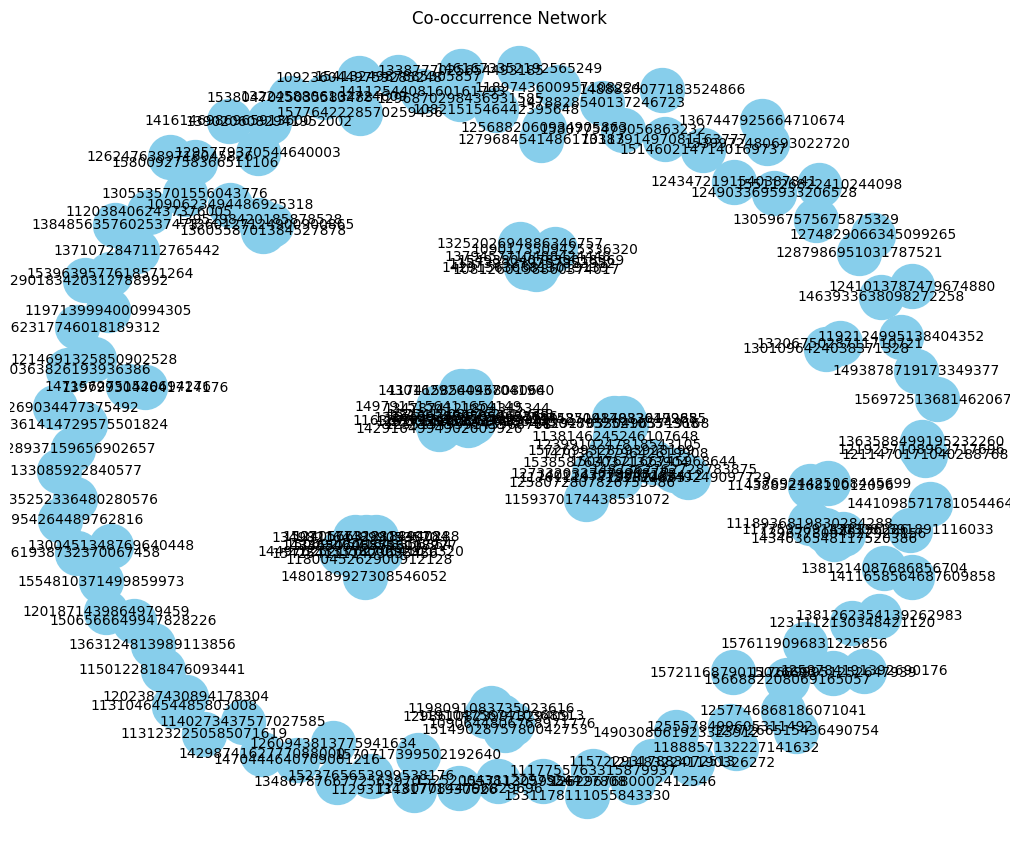

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and it has 'word' and 'message_id' columns
# Step 1: Create a pivot table
pivot_table = pd.pivot_table(df, index='word', columns='message_id', aggfunc='size', fill_value=0)

# Step 2: Compute the co-occurrence matrix
# Convert the pivot table into a boolean presence-absence table (1 if word is present in message, 0 otherwise)
binary_presence = pivot_table.apply(lambda x: x > 0).astype(int)

# Use matrix multiplication to get the co-occurrence matrix
co_occurrence_matrix = binary_presence.T.dot(binary_presence)

# Zero out the diagonal, so we don't count a word co-occurring with itself
np.fill_diagonal(co_occurrence_matrix.values, 0)

# Step 3: Create a graph from the co-occurrence matrix
G = nx.from_pandas_adjacency(co_occurrence_matrix)

# Step 4: Draw the graph
plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, node_color='skyblue', node_size=1000, edge_color='gray', linewidths=1, font_size=10)
plt.title('Co-occurrence Network')
plt.show()


In [ ]:
# Testing lemmatization (apparentely not needed )

"""
# Initialize an empty DataFrame to store the comparison results
comparison_df = pd.DataFrame(columns=['message_id', 'unique_words_original', 'unique_words_lemmatized'])

# Convert your list of dictionaries into a DataFrame
ner_results_df = pd.DataFrame(ner_results_records)

# Now, proceed with the previously discussed logic
rows_to_add = []

for message_id, group in ner_results_df.groupby("message_id"):
    original_words = group[group['text_type'] == 'original']['word'].unique()
    lemmatized_words = group[group['text_type'] == 'lemmatized']['word'].unique()

    # Find words unique to each text type
    original_unique = set(original_words) - set(lemmatized_words)
    lemmatized_unique = set(lemmatized_words) - set(original_words)

    # Prepare a row as a dictionary
    row = {
        'message_id': message_id,
        'original_unique_words': ", ".join(original_unique),
        'lemmatized_unique_words': ", ".join(lemmatized_unique)
    }
    # Append the row dictionary to the list
    rows_to_add.append(row)

# Create a DataFrame from the list of dictionaries
comparison_df = pd.DataFrame(rows_to_add)
"""

In [ ]:
comparison_df

,message_id,original_unique_words,lemmatized_unique_words
0,1081260198860374017,"Danmark, Said Mansour",
1,1082151546442395648,EU -,
2,1090173509425336320,"Zlatan Ibrahimovic, Sverige",
3,1090623494486925318,"anderssamuelsen, Den Islamiske Republik Iran, ...",
4,1090644806768971776,"Elvir Abaz, Fyns Politi, Rasmus Paludan, Polit...",
...,...,...,...
159,1576119096831225856,StineLacoul,
160,1576924425068445699,"radikale, Dansk Militær, Borgerlig Politik",
161,1577642228570259456,"Wikipedia, den frie encyklopædi",
162,1580092758366511106,Søren Pape,


In [ ]:
ner_results_df["entity_group"].value_counts()
#ner_results_df["text_type"].value_counts()

PER     290
ORG     208
MISC    179
LOC      98
Name: entity_group, dtype: int64

In [ ]:
import pandas as pd

# Assuming ner_results_records is a list of dictionaries as before
ner_results_df = pd.DataFrame(ner_results_records)

# Filter by text_type
original_words_df = ner_results_df[ner_results_df['text_type'] == 'original']
lemmatized_words_df = ner_results_df[ner_results_df['text_type'] == 'lemmatized']

# Aggregate words into sets for easy comparison
original_words_set = set(original_words_df['word'].unique())
lemmatized_words_set = set(lemmatized_words_df['word'].unique())

# Find words that are in original but not in lemmatized and vice versa
words_in_original_not_in_lemmatized = original_words_set.difference(lemmatized_words_set)
words_in_lemmatized_not_in_original = lemmatized_words_set.difference(original_words_set)

# Count the differences
num_words_in_original_not_in_lemmatized = len(words_in_original_not_in_lemmatized)
num_words_in_lemmatized_not_in_original = len(words_in_lemmatized_not_in_original)

# Print the differences
print(f"Words in original but not in lemmatized ({num_words_in_original_not_in_lemmatized} words):")
print(words_in_original_not_in_lemmatized)
print(f"Words in lemmatized but not in original ({num_words_in_lemmatized_not_in_original} words):")
print(words_in_lemmatized_not_in_original)


In [ ]:
# Define a function to filter entities based on score
def filter_entities(entities, cutoff=0.5):
    return [entity for entity in entities if entity['score'] < cutoff]

# Create a new column 'cut_off_entities' to store entities cut off from 'ner_results'
df_sam['cut_off_entities'] = df_sam['ner_results'].apply(filter_entities)

# Display the DataFrame with the cut off entities
df_sam[['ner_results', 'ner_results_lemma','cut_off_entities']]


,ner_results,ner_results_lemma,cut_off_entities
2630113,"[{'entity_group': 'LOC', 'score': 0.9995059, '...","[{'entity_group': 'LOC', 'score': 0.99949145, ...",[]
2646516,"[{'entity_group': 'MISC', 'score': 0.9983469, ...","[{'entity_group': 'MISC', 'score': 0.998175, '...",[]
4960618,"[{'entity_group': 'PER', 'score': 0.76422256, ...","[{'entity_group': 'PER', 'score': 0.8281002, '...",[]
3123805,"[{'entity_group': 'PER', 'score': 0.59067106, ...",[],[]
2928438,"[{'entity_group': 'PER', 'score': 0.4994545, '...","[{'entity_group': 'PER', 'score': 0.4994545, '...","[{'entity_group': 'PER', 'score': 0.4994545, '..."
...,...,...,...
2670980,"[{'entity_group': 'ORG', 'score': 0.836579, 'w...","[{'entity_group': 'ORG', 'score': 0.85166085, ...",[]
2630435,"[{'entity_group': 'PER', 'score': 0.99926037, ...","[{'entity_group': 'PER', 'score': 0.9991003, '...",[]
79403,"[{'entity_group': 'PER', 'score': 0.9997987, '...","[{'entity_group': 'PER', 'score': 0.9997707, '...",[]
2136631,[],[],[]


In [ ]:
import pandas as pd

# Sample DataFrame with 'ner_results' column
# Assuming df_sam['ner_results'] contains NER results as dictionaries

# Extract unique entity groups
unique_entity_groups = set()
for entities in df_sam['ner_results']:
    for entity in entities:
        unique_entity_groups.add(entity['entity_group'])

# Convert unique_entity_groups to a list
unique_entity_groups_list = list(unique_entity_groups)

# Create a new DataFrame to store counts of unique entity groups
entity_group_counts = pd.DataFrame(0, index=[0], columns=unique_entity_groups_list)

# Count occurrences of each entity group
for entities in df_sam['ner_results']:
    for entity in entities:
        entity_group_counts[entity['entity_group']] += 1

# Display the DataFrame with counts of unique entity groups
print(entity_group_counts)


    LOC   PER   ORG  MISC
0  1469  3936  2405  2373


In [ ]:
import pandas as pd

# Initialize a dictionary to store counts of each entity value within each entity group
entity_group_counts = {}

# Iterate over each row in df_sam['ner_results']
for entities in df_sam['ner_results']:
    # Iterate over each entity in the row's NER results
    for entity in entities:
        # Extract entity group and entity value
        entity_group = entity['entity_group']
        entity_value = entity['word']

        # If the entity group is not in the dictionary, add it with an empty dictionary
        if entity_group not in entity_group_counts:
            entity_group_counts[entity_group] = {}

        # If the entity value is not in the dictionary for the entity group, add it with a count of 1
        if entity_value not in entity_group_counts[entity_group]:
            entity_group_counts[entity_group][entity_value] = 1
        # If the entity value is already in the dictionary for the entity group, increment its count
        else:
            entity_group_counts[entity_group][entity_value] += 1

# Convert the dictionary to a DataFrame
entity_group_counts_df = pd.DataFrame(entity_group_counts)

# Fill NaN values with 0
entity_group_counts_df = entity_group_counts_df.fillna(0)

# Convert DataFrame values to int64
entity_group_counts_df = entity_group_counts_df.astype('int64')
# Reset the index of the DataFrame and rename the index column to "entity"
entity_group_counts_df = entity_group_counts_df.reset_index().rename(columns={'index': 'entity'})

# Display the DataFrame
entity_group_counts_df


,entity,ORG,MISC,PER,LOC
0,Bundestag,1,0,0,0
1,Europarådets,1,0,0,0
2,tv2newsdk,23,2,0,0
3,Ukraine,1,1,0,17
4,dkmedier,4,8,0,0
...,...,...,...,...,...
4073,Gråsten,0,0,0,1
4074,Delmi,0,0,0,1
4075,mellemøsten,0,0,0,1
4076,Danskernes Hus,0,0,0,1


In [ ]:
import pandas as pd

# Text normalization
entity_group_counts_df['normalized_entity'] = entity_group_counts_df['entity'].str.lower()

# Group by the normalized_entity column and sum the counts for each entity group
merged_entities_df = entity_group_counts_df.groupby('normalized_entity').sum()

# Reset the index to make 'normalized_entity' a column again
merged_entities_df.reset_index(inplace=True)

# Display the merged DataFrame
merged_entities_df


<ipython-input-18-3c6c8fddf1c6>:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  merged_entities_df = entity_group_counts_df.groupby('normalized_entity').sum()


,normalized_entity,ORG,MISC,PER,LOC
0,#,0,3,0,0
1,# 5g,0,1,0,0
2,# crown,1,0,0,0
3,# dkkultur,0,1,0,0
4,# u2,1,0,0,0
...,...,...,...,...,...
3865,østrigs,1,0,0,0
3866,østrigske,0,1,0,0
3867,øv,0,1,0,0
3868,øzlem,0,0,1,0


In [ ]:
# End the timer
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time

# Display the elapsed time
print("Total execution time:", elapsed_time, "seconds")

# 854.619115114212 seconds for 5000 social media texts

Total execution time: 854.619115114212 seconds


In [ ]:
import pandas as pd

# Define a new DataFrame for NER results
columns=['message_id', 'entity_group', 'score', 'word', 'start', 'end', 'text_type']
ner_results_list = []

# Process each row in your original DataFrame
for index, row in df_sam.iterrows():
    message_id = row['message_id']

    # Process original text
    text = row['text']
    for entity in nlp(text):
        ner_results_list.append({
            'message_id': message_id,
            'entity_group': entity['entity_group'],
            'score': entity['score'],
            'word': entity['word'],
            'start': entity['start'],
            'end': entity['end'],
            'text_type': 'original'
        })

    # Process lemmatized text if it exists
    if 'text_lem' in row:
        text_lem = row['text_lem']
        for entity in nlp(text_lem):
            ner_results_list.append({
                'message_id': message_id,
                'entity_group': entity['entity_group'],
                'score': entity['score'],
                'word': entity['word'],
                'start': entity['start'],
                'end': entity['end'],
                'text_type': 'lemmatized'
            })

# Convert list of dictionaries to DataFrame
ner_results_df = pd.DataFrame(ner_results_list, columns=columns)

# Filter results based on confidence score greater than 0.5
ner_results_filtered = ner_results_df[ner_results_df['score'] > 0.5]

# If you want to add a simplified representation back to the original DataFrame, you can count occurrences or create summary statistics.
# For example, count NER occurrences per message_id
ner_summary = ner_results_filtered.groupby(['message_id', 'entity_group']).size().reset_index(name='counts')

# Merge summary back to the original DataFrame if needed
df_sam = pd.merge(df_sam, ner_summary, on='message_id', how='left')

# Display the updated DataFrame
print(df_sam)


               message_id                                               text  \
0     1566721664339034112  RT @KirkegaardDane: Kan det siges mere præcist 👇🏻   
1     1280839594574065667  @per68ter @BulgariaDK ⚠️⚠️⚠️‼️⚠️⚠️⚠️Advarsel :...   
2     1280839594574065667  @per68ter @BulgariaDK ⚠️⚠️⚠️‼️⚠️⚠️⚠️Advarsel :...   
3     1143136024245211136  RT [at]KoeppelRoger: Klimapopulismus.  https:/...   
4     1425719202653036546  https://t.co/reP6AAgGKQ\nFor meget for bonerte...   
...                   ...                                                ...   
1561  1258711414526685186  @Rikke66086382 Fordi lille Kristian er et fork...   
1562  1347890859803619328  @viggo1986 Mette F skal nok finde på noget: At...   
1563  1347890859803619328  @viggo1986 Mette F skal nok finde på noget: At...   
1564  1580216693733101568  RT @s_elkj: Miljøminister Lea Wermelin er ny Y...   
1565  1580216693733101568  RT @s_elkj: Miljøminister Lea Wermelin er ny Y...   

                                       

In [ ]:
df_sam

,message_id,text,text_lem,entity_group,counts
0,1566721664339034112,RT @KirkegaardDane: Kan det siges mere præcist 👇🏻,RT @KirkegaardDane: Kane den sige mere præcist 👇🏻,PER,2.0
1,1280839594574065667,@per68ter @BulgariaDK ⚠️⚠️⚠️‼️⚠️⚠️⚠️Advarsel :...,@per68te @BulgariaDK ⚠️⚠️⚠️‼️⚠️⚠️⚠️Advarsel : ...,LOC,2.0
2,1280839594574065667,@per68ter @BulgariaDK ⚠️⚠️⚠️‼️⚠️⚠️⚠️Advarsel :...,@per68te @BulgariaDK ⚠️⚠️⚠️‼️⚠️⚠️⚠️Advarsel : ...,ORG,6.0
3,1143136024245211136,RT [at]KoeppelRoger: Klimapopulismus. https:/...,RT [at]KoeppelRoger: Klimapopulismuservativ ht...,PER,2.0
4,1425719202653036546,https://t.co/reP6AAgGKQ\nFor meget for bonerte...,https://t.co/reP6AAgGKQ For megen for bonert p...,ORG,6.0
...,...,...,...,...,...
1561,1258711414526685186,@Rikke66086382 Fordi lille Kristian er et fork...,@Rikke66086382 Fordi lille Kristian være et fo...,PER,4.0
1562,1347890859803619328,@viggo1986 Mette F skal nok finde på noget: At...,@viggo1986 Mette F skal nok finde på noget: At...,LOC,2.0
1563,1347890859803619328,@viggo1986 Mette F skal nok finde på noget: At...,@viggo1986 Mette F skal nok finde på noget: At...,PER,4.0
1564,1580216693733101568,RT @s_elkj: Miljøminister Lea Wermelin er ny Y...,RT @s_elkj: Miljøminister Lea Wermelin være ny...,MISC,2.0


# Code not used

In [ ]:
"""
# Initialize ner_results list before the loop
ner_results = []

for index, row in df_sam.iterrows():
    text = row['text']
    message_id = row['message_id']
    result = nlp(text)
    # Append results along with message_id for identification
    ner_results.append({'message_id': message_id, 'ner_result': result})

len(ner_results)
"""

"\n# Initialize ner_results list before the loop\nner_results = []\n\nfor index, row in df_sam.iterrows():\n    text = row['text']\n    message_id = row['message_id']\n    result = nlp(text)\n    # Append results along with message_id for identification\n    ner_results.append({'message_id': message_id, 'ner_result': result})\n\nlen(ner_results)\n"

In [ ]:
"""
# Initialize ner_results list before the loop
ner_results = []

for index, row in df_sam.iterrows():
    # Process original text
    text = row['text']
    message_id = row['message_id']
    result_text = nlp(text)
    # Append results for original text
    ner_results.append({'message_id': message_id, 'source': 'text', 'ner_result': result_text})

    # Process lemmatized text if it exists
    if 'text_lem' in row:
        text_lem = row['text_lem']
        result_text_lem = nlp(text_lem)
        # Append results for lemmatized text
        ner_results.append({'message_id': message_id, 'source': 'text_lem', 'ner_result': result_text_lem})

# Display the total number of NER results
len(ner_results)
"""

"\n# Initialize ner_results list before the loop\nner_results = []\n\nfor index, row in df_sam.iterrows():\n    # Process original text\n    text = row['text']\n    message_id = row['message_id']\n    result_text = nlp(text)\n    # Append results for original text\n    ner_results.append({'message_id': message_id, 'source': 'text', 'ner_result': result_text})\n    \n    # Process lemmatized text if it exists\n    if 'text_lem' in row:\n        text_lem = row['text_lem']\n        result_text_lem = nlp(text_lem)\n        # Append results for lemmatized text\n        ner_results.append({'message_id': message_id, 'source': 'text_lem', 'ner_result': result_text_lem})\n\n# Display the total number of NER results\nlen(ner_results)\n"

In [ ]:
import pandas as pd

# Initialize a list to hold NER result records
ner_results_records = []

for index, row in df_sam.iterrows():
    # Process original text
    text = row['text']
    message_id = row['message_id']
    result_text = nlp(text)
    # Create records for original text NER results
    for entity in result_text:
        ner_results_records.append({
            'message_id': message_id,
            'text_type': 'original',
            'entity_group': entity['entity_group'],
            'score': entity['score'],
            'word': entity['word'],
            'start': entity['start'],
            'end': entity['end']
        })
"""
    # Process lemmatized text if it exists
    if 'text_lem' in row:
        text_lem = row['text_lem']
        result_text_lem = nlp(text_lem)
        # Create records for lemmatized text NER results
        for entity in result_text_lem:
            ner_results_records.append({
                'message_id': message_id,
                'text_type': 'lemmatized',
                'entity_group': entity['entity_group'],
                'score': entity['score'],
                'word': entity['word'],
                'start': entity['start'],
                'end': entity['end']
            })
"""
# Convert the records into a DataFrame
ner_results_df = pd.DataFrame(ner_results_records)
ner_results_filtered = ner_results_df[ner_results_df['score'] > 0.5]


In [ ]:
# Initialize ner_results lists before the loop
ner_results = []
ner_results_lemma = []

for index, row in df_sam.iterrows():
    # Process original text
    text = row['text']
    message_id = row['message_id']
    result_text = nlp(text)
    # Append results for original text
    ner_results.append(result_text)

    # Process lemmatized text if it exists
    if 'text_lem' in row:
        text_lem = row['text_lem']
        result_text_lem = nlp(text_lem)
        # Append results for lemmatized text
        ner_results_lemma.append(result_text_lem)


ner_results
# Add columns to the DataFrame for NER results
df_sam['ner_results'] = ner_results
df_sam['ner_results_lemma'] = ner_results_lemma
df_sam['ner_results_04_cutoff'] = df_sam['ner_results'].apply(lambda x: [entity for entity in x if entity['score'] > 0.5])

# Display the total number of NER results
len(df_sam)